In [2]:
from dotenv import load_dotenv
import os

load_dotenv()

True

In [19]:
from google import genai

client = genai.Client()  # uses GOOGLE_API_KEY from env by default
for m in client.models.list():
    print(m.name, getattr(m, "supported_actions", None))

models/gemini-2.5-flash ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.5-pro ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash-001 ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash-lite-001 ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash-lite ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.5-flash-preview-tts ['countTokens', 'generateContent']
models/gemini-2.5-pro-preview-tts ['countTokens', 'generateContent', 'batchGenerateContent']
models/gemma-3-1b-it ['generateContent', 'countTokens']
models/gemma-3-4b-it ['generateContent', 'countTokens']
models/gemma-3-12b-it ['generateContent', 'countTokens']
models/gemma-3-

In [ ]:
#Get https://generativelanguage.googleapis.com/v1beta/models
import requests
res = requests.get("https://generativelanguage.googleapis.com/v1beta/models?key=" 
+ os.getenv("GOOGLE_API_KEY"))
res.json()

{'models': [{'name': 'models/gemini-2.5-flash',
   'version': '001',
   'displayName': 'Gemini 2.5 Flash',
   'description': 'Stable version of Gemini 2.5 Flash, our mid-size multimodal model that supports up to 1 million tokens, released in June of 2025.',
   'inputTokenLimit': 1048576,
   'outputTokenLimit': 65536,
   'supportedGenerationMethods': ['generateContent',
    'countTokens',
    'createCachedContent',
    'batchGenerateContent'],
   'temperature': 1,
   'topP': 0.95,
   'topK': 64,
   'maxTemperature': 2,
   'thinking': True},
  {'name': 'models/gemini-2.5-pro',
   'version': '2.5',
   'displayName': 'Gemini 2.5 Pro',
   'description': 'Stable release (June 17th, 2025) of Gemini 2.5 Pro',
   'inputTokenLimit': 1048576,
   'outputTokenLimit': 65536,
   'supportedGenerationMethods': ['generateContent',
    'countTokens',
    'createCachedContent',
    'batchGenerateContent'],
   'temperature': 1,
   'topP': 0.95,
   'topK': 64,
   'maxTemperature': 2,
   'thinking': True},
 

In [3]:
# from langchain_google_gemini import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langchain.chat_models import init_chat_model

llm = init_chat_model("google_genai:gemini-2.5-flash")
llm.invoke("Hello, how many days are in a persian year?")

AIMessage(content='A Persian year (based on the Jalali calendar) typically has **365 days**.\n\nHowever, during a leap year (known as سال کبیسه - *sāl-e kabise*), it has **366 days**. The extra day is added to the last month, Esfand (اسفند), making it 30 days long instead of the usual 29 days in a leap year.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019de009-6c18-7400-a779-1d317b7d3a7c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 320, 'total_tokens': 332, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 232}})

In [4]:
from typing import TypedDict, Annotated
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage

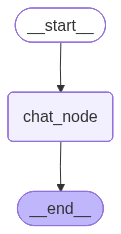

In [5]:
class ChatState(TypedDict):
    # messages: list[str]
    messages: Annotated[list, add_messages] #add_messages is a reducer function, it appends the message to the list. 



def chat_node(state: ChatState) -> ChatState:
    # return {"messages": [f"user: {state['messages'][-1]}"]}
    ai_reply = llm.invoke(state["messages"])   # returns AIMessage
    return {"messages": [ai_reply]}            # add_messages appends it
    # last = state["messages"][-1]
    # return {"messages": [AIMessage(content=f"user said: {last.content}")]}

builder = StateGraph(ChatState)
builder.add_node("chat_node", chat_node)

builder.add_edge(START, "chat_node")
builder.add_edge("chat_node", END)

graph = builder.compile()
graph

In [6]:
# 4) Invoke graph
result = graph.invoke({
    "messages": [HumanMessage(content="Who walked on the moon for the first time?Print only the name")]
})
for m in result["messages"]:
    print(type(m).__name__, "->", m.content)

HumanMessage -> Who walked on the moon for the first time?Print only the name
AIMessage -> Neil Armstrong


In [ ]:
# Try to maintain memory of the conversation. Not the best way to do it though!

state: ChatState = {"messages": []}
while True:
    user_text = input("You: ").strip()
    if user_text.lower() in {"quit","exit"}:
        break
    if not user_text:
        continue
    state["messages"].append(HumanMessage(content=user_text))

    state = graph.invoke(state)
    print("Bot:", state["messages"][-1].content)

Bot: It's **2024**.

Did you have a specific year in mind, or were you asking about the current year?
Bot: The first person to walk on the moon was **Neil Armstrong**.

He made that historic step on July 20, 1969, during the Apollo 11 mission.
Bot: The first person to walk on the moon was **Neil Armstrong**.
Bot: Neil Armstrong
Bot: Neil Armstrong
Bot: He was **38 years old** when he walked on the moon.
Bot: He was **38 years old** when he walked on the moon.
Bot: Okay, here's a surprising fact related to the moon landing:

Astronauts who walked on the moon reported that the moon dust they brought back into the lunar module had a distinct smell – often described as similar to **spent gunpowder** or "acrid." This was a surprise because there's no air on the moon for anything to have a smell! They only noticed it once the dust was exposed to the oxygen inside the spacecraft.
Bot: Okay, here's a surprising space fact for you:

On gas giant planets like **Jupiter and Saturn**, scientists b